# Homework 2

## FINM 35700 - Spring 2026

### UChicago Financial Mathematics

### Due Date: 2026-04-07

* Yiyang Yu
* yiyangyu@uchicago.edu

This homework relies on:

- the corporate and government bonds symbology file `bond_symbology`, 
- the "on-the-run" treasuries data file `govt_on_the_run`,
- the bond market data file `bond_market_prices_eod`, containing EOD price data as of 2026-03-23.

------------------------------------------------------------------------------------------
# Problem 1: Constructing fixed rate bonds

In [59]:
import QuantLib as ql
import pandas as pd
import datetime as dt
from IPython.display import display
import numpy as np
pd.reset_option('display.max_columns')
import matplotlib.pyplot as plt

# Use static calculation/valuation date of 2026-03-23, matching data available in the market prices EOD file
calc_date = ql.Date(23, 3, 2026)
ql.Settings.instance().evaluationDate = calc_date

## a. Prepare the symbology and market data files for fixed rate government and corporate bonds

Load the `bond_symbology`, `bond_market_prices_eod` and `govt_on_the_run` Excel files into dataframes.

Filter the symbology frame for fixed rate bonds only (cpn_type="FIXED").


In [60]:
bond_symbology = pd.read_excel('data/bond_symbology.xlsx')
bond_market_prices_eod = pd.read_excel('data/bond_market_prices_eod.xlsx')
govt_on_the_run = pd.read_excel('data/govt_on_the_run.xlsx')
bond_symbology_fixed = bond_symbology[bond_symbology['cpn_type'] == 'FIXED']
display(bond_symbology_fixed.head(3))
display(govt_on_the_run.head(3))
display(bond_market_prices_eod.head(3))


,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status
0,AAPL,Corp,BBG004HST0K7,US037833AL42,US912810UT33,AAPL 3.85 05/04/43,APPLE INC,GLOBAL,3.85,FIXED,...,2013-05-03,2013-11-04,2013-05-03,2043-05-04,AT MATURITY,Sr Unsecured,3000.0,US,USD,ACTV
1,AAPL,Corp,BBG006F8VWJ7,US037833AT77,US912810UT33,AAPL 4.45 05/06/44,APPLE INC,GLOBAL,4.45,FIXED,...,2014-05-06,2014-11-06,2014-05-06,2044-05-06,AT MATURITY,Sr Unsecured,1000.0,US,USD,ACTV
2,AAPL,Corp,BBG0081TNL50,US037833BA77,US912810UT33,AAPL 3.45 02/09/45,APPLE INC,GLOBAL,3.45,FIXED,...,2015-02-09,2015-08-09,2015-02-09,2045-02-09,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV


,ticker,date,figi,isin
0,GT10 Govt,2026-03-23,BBG01ZZ4GDR9,US91282CPZ85
1,GT10B Govt,2026-03-23,BBG01Y9RFK31,US91282CPJ44
2,GT10C Govt,2026-03-23,BBG01WCQ4BQ0,US91282CNT44


,date,class,ticker,isin,figi,bidPrice,askPrice,bidYield,askYield
0,2026-03-23,Corp,AAPL,US037833AL42,BBG004HST0K7,82.414444,82.414444,5.442,5.442
1,2026-03-23,Corp,AAPL,US037833AT77,BBG006F8VWJ7,89.116091,89.116091,5.399,5.399
2,2026-03-23,Corp,AAPL,US037833BA77,BBG0081TNL50,75.855577,75.855577,5.526,5.526


## b. Add a function to construct generic fixed rate cashflow schedules from symbology data

Use one row of the symbology dataframe as input  to the function. Use the helper function to convert a date string to a QuantLib date object.

Identify and display the `AAPL 1.65 05/11/30` bond details in the symbology dataframe. Use create_schedule_from_symbology() to generate and display the cashflow schedule for `AAPL 1.65 05/11/30`.


In [61]:
row = bond_symbology_fixed.loc[(bond_symbology_fixed['ticker'] == 'AAPL') & (bond_symbology_fixed['maturity'] == '2030-05-11')]
display(row)

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status
17,AAPL,Corp,BBG00TN2PMV6,US037833DU14,US91282CQD64,AAPL 1.65 05/11/30,APPLE INC,GLOBAL,1.65,FIXED,...,2020-05-11,2020-11-11,2020-05-11,2030-05-11,CALLABLE,Sr Unsecured,1750.0,US,USD,ACTV


In [62]:
def get_ql_date(date) -> ql.Date:
    """
    convert dt.date to ql.Date
    """
    if isinstance(date, dt.date):
        return ql.Date(date.day, date.month, date.year)
    elif isinstance(date, str):
        date = dt.datetime.strptime(date, "%Y-%m-%d").date()
        return ql.Date(date.day, date.month, date.year)
    else:
        raise ValueError(f"to_qldate, {type(date)}, {date}")

In [63]:
def create_schedule_from_symbology(details: dict):
    '''Create a QuantLib cashflow schedule from symbology details dictionary (usually one row of the symbology dataframe)
    '''

    # Create maturity from details['maturity']
    maturity = get_ql_date(details['maturity'])
    
    # Create acc_first from details['acc_first']
    acc_first = get_ql_date(details['acc_first'])
    
    # Create calendar for Corp and Govt asset classes
    calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    
    # define period from details['cpn_freq'] ... can be hard-coded to 2 = semi-annual frequency
    period = ql.Period(2)
    
    # business_day_convention
    business_day_convention = ql.Unadjusted
    
    # termination_date_convention
    termination_date_convention = ql.Unadjusted
    
    # date_generation
    date_generation=ql.DateGeneration.Backward
    
    # Create schedule using ql.MakeSchedule interface (with keyword arguments)
    schedule = ql.MakeSchedule(effectiveDate=acc_first,  # this may not be the same as the bond's start date
                            terminationDate=maturity,
                            tenor=period,
                            calendar=calendar,
                            convention=business_day_convention,
                            terminalDateConvention=termination_date_convention,
                            rule=date_generation,
                            endOfMonth=True,
                            firstDate=ql.Date(),
                            nextToLastDate=ql.Date())
    return schedule

In [64]:
AAPL_165_2030_schedule = create_schedule_from_symbology(row.iloc[0].to_dict())
AAPL_165_2030_schedule

<QuantLib.QuantLib.Schedule; proxy of <Swig Object of type 'Schedule *' at 0x12541ea70> >

## c. Add a function to construct generic fixed rate bond objects from symbology data

Implement the  create_bond_from_symbology() function below. 

Use create_bond_from_symbology() to generate the fixed rate bond object `AAPL 1.65 05/11/30`.


In [65]:
def create_bond_from_symbology(details: dict):
    '''Create a US fixed rate bond object from symbology details dictionary (usually one row of the symbology dataframe)
    '''
    # Create day_count from details['start_date']
    # Create day_count from details['dcc']
    # For US Treasuries use ql.ActualActual(ql.ActualActual.ISMA)
    # For US Corporate bonds use ql.Thirty360(ql.Thirty360.USA)

    if details['class'] == 'Corp':
        day_count = ql.Thirty360(ql.Thirty360.USA)   # update code depending on dcc !!!
    else:
        day_count = ql.ActualActual(ql.ActualActual.ISMA)   # update code depending on dcc !!!
  
    issue_date = get_ql_date(details['start_date'])      # use date helper function and update code !!!
    
    # Create days_settle from details['days_settle']
    days_settle = details['days_settle']        # update code depending on days_settle !!!

    # Create days_settle from details['coupon']
    coupon = float(details['coupon']) / 100.0      # update code depending on coupon !!!

    # Create cashflow schedule
    schedule = create_schedule_from_symbology(details)
    
    face_value = 100
    redemption = 100
    
    payment_convention = ql.Unadjusted
        
    # Create fixed rate bond object
    fixed_rate_bond = ql.FixedRateBond(
        days_settle,
        face_value,
        schedule,
        [coupon],
        day_count,
        payment_convention,
        redemption,
        issue_date)        

    return fixed_rate_bond


In [66]:
AAPL_bond = create_bond_from_symbology(bond_symbology[bond_symbology['security'] == 'AAPL 1.65 05/11/30'].iloc[0].to_dict())
AAPL_bond

<QuantLib.QuantLib.FixedRateBond; proxy of <Swig Object of type 'ext::shared_ptr< FixedRateBond > *' at 0x125734930> >

## d. Add function that returns a dataframe with (future) cash flows details for a bond object

Use the "Investigate Bond Cashflows" section in the Quantlib introductory notebook as a template.

The results dataframe should contain following columns:


| CashFlowDate | CashFlowAmount | CashFlowYearFrac |
|----------|-------|-------------|

Create the bond objects and display the future cashflows for following securities:

* the `T 4 1/2 02/15/36` government bond and 
* the `AAPL 1.65 05/11/30` corporate bond.

In [67]:
def get_bond_cashflows(bond: ql.FixedRateBond, calc_date: ql.Date = None) -> pd.DataFrame:
    '''Returns all future cashflows as of calc_date, i.e. with payment dates > calc_date.
    Columns: CashFlowDate, CashFlowAmount, CashFlowYearFrac
    '''
    if calc_date is None:
        calc_date = bond.startDate()

    day_count = bond.dayCounter()

    x = [
        (cf.date(), cf.amount(), day_count.yearFraction(calc_date, cf.date()))
        for cf in bond.cashflows()
        if cf.date() > calc_date
    ]
    cf_dates, cf_amounts, cf_yearfracs = zip(*x)

    cashflows_df = pd.DataFrame({
        'CashFlowDate': cf_dates,
        'CashFlowAmount': cf_amounts,
        'CashFlowYearFrac': cf_yearfracs
    })

    return cashflows_df

t_bond_details = bond_symbology[bond_symbology['security'] == 'T 4 1/2 02/15/36'].iloc[0].to_dict()
aapl_bond_details = bond_symbology[bond_symbology['security'] == 'AAPL 1.65 05/11/30'].iloc[0].to_dict()

t_bond = create_bond_from_symbology(t_bond_details)
aapl_bond = create_bond_from_symbology(aapl_bond_details)
display(get_bond_cashflows(t_bond, calc_date))
display(get_bond_cashflows(aapl_bond, calc_date))

,CashFlowDate,CashFlowAmount,CashFlowYearFrac
0,"August 15th, 2026",2.25,0.416667
1,"February 15th, 2027",2.25,0.916667
2,"August 15th, 2027",2.25,1.416667
3,"February 15th, 2028",2.25,1.916667
4,"August 15th, 2028",2.25,2.416667
5,"February 15th, 2029",2.25,2.916667
6,"August 15th, 2029",2.25,3.416667
7,"February 15th, 2030",2.25,3.916667
8,"August 15th, 2030",2.25,4.416667
9,"February 15th, 2031",2.25,4.916667


,CashFlowDate,CashFlowAmount,CashFlowYearFrac
0,"May 11th, 2026",0.825,0.133333
1,"November 11th, 2026",0.825,0.633333
2,"May 11th, 2027",0.825,1.133333
3,"November 11th, 2027",0.825,1.633333
4,"May 11th, 2028",0.825,2.133333
5,"November 11th, 2028",0.825,2.633333
6,"May 11th, 2029",0.825,3.133333
7,"November 11th, 2029",0.825,3.633333
8,"May 11th, 2030",0.825,4.133333
9,"May 11th, 2030",100.000,4.133333


------------------------------------------------------------------------------------------
# Problem 2: US Treasury yield curve calibration (On-The-Runs)

## a. Create the on-the-run US treasury bond objects

Restrict the symbology + market data dataframe to "on-the-run"/OTR US treasury notes/bonds only and create the treasury bond objects.

Extend the treasuries symbology dataframe with the following market data columns (code from Homework 1):


| date | bidPrice | askPrice | midPrice | bidYield | askYield | midYield | term | TTM |
|----------|-------|-------------|-----|----------|---------|---------|---------|---------|

Plot a graph/scatter plot of on-the-run treasury mid yields by TTM.

In [68]:
govt_bonds_df = pd.read_excel('data/govt_on_the_run.xlsx')
bond_market_prices_df = pd.read_excel('data/bond_market_prices_eod.xlsx')
pattern = r'GT[0-9]+ Govt'
mask = govt_bonds_df['ticker'].str.contains(pattern, regex=True)
govt_bonds_df = govt_bonds_df[mask]
on_the_run_govt_bonds_df = bond_symbology[bond_symbology['isin'].isin(govt_bonds_df['isin']) & (bond_symbology['figi'].isin(govt_bonds_df['figi']))]
on_the_run_govt_bonds_df['term'] = (on_the_run_govt_bonds_df['maturity'] - on_the_run_govt_bonds_df['start_date']).dt.days/ 365.25
on_the_run_govt_bonds_df['TTM'] = np.maximum((on_the_run_govt_bonds_df['maturity'] - pd.to_datetime('2026-03-23')).dt.days/ 365.25, 0)
on_the_run_govt_bonds_df.sort_values(by='maturity', inplace=True)
on_the_run_treasury = on_the_run_govt_bonds_df.merge(bond_market_prices_df, on=['figi', 'isin'], how = 'inner')
on_the_run_treasury['midPrice'] = (on_the_run_treasury['bidPrice'] + on_the_run_treasury['askPrice']) / 2
on_the_run_treasury['midYield'] = (on_the_run_treasury['bidYield'] + on_the_run_treasury['askYield']) / 2
on_the_run_treasury.drop(columns=['ticker_y', 'class_y'], inplace=True)
on_the_run_treasury.rename(columns={'ticker_x': 'ticker', 'class_x': 'class'}, inplace=True)
display(on_the_run_treasury.head())

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,status,term,TTM,date,bidPrice,askPrice,bidYield,askYield,midPrice,midYield
0,T,Govt,BBG020BMV715,US91282CQB09,US91282CQB09,T 3 3/8 02/29/28,US TREASURY N/B,US GOVERNMENT,3.375,FIXED,...,ACTV,1.995893,1.938398,2026-03-23,99.1562,99.1601,3.856,3.852,99.15815,3.8540
1,T,Govt,BBG020PVMGR2,US91282CQE48,US91282CQE48,T 3 1/2 03/15/29,US TREASURY N/B,US GOVERNMENT,3.500,FIXED,...,ACTV,2.997947,2.978782,2026-03-23,99.0390,99.0468,3.867,3.864,99.04290,3.8655
2,T,Govt,BBG020BMV760,US91282CQD64,US91282CQD64,T 3 1/2 02/28/31,US TREASURY N/B,US GOVERNMENT,3.500,FIXED,...,ACTV,4.993840,4.936345,2026-03-23,98.0000,98.0156,3.969,3.966,98.00780,3.9675
3,T,Govt,BBG020BMV6Z0,US91282CQC81,US91282CQC81,T 3 3/4 02/28/33,US TREASURY N/B,US GOVERNMENT,3.750,FIXED,...,ACTV,6.995209,6.937714,2026-03-23,97.6562,97.6718,4.158,4.153,97.66400,4.1555
4,T,Govt,BBG01ZZ4GDR9,US91282CPZ85,US91282CPZ85,T 4 1/8 02/15/36,US TREASURY N/B,US GOVERNMENT,4.125,FIXED,...,ACTV,9.993155,9.900068,2026-03-23,98.3125,98.3437,4.348,4.342,98.32810,4.3450


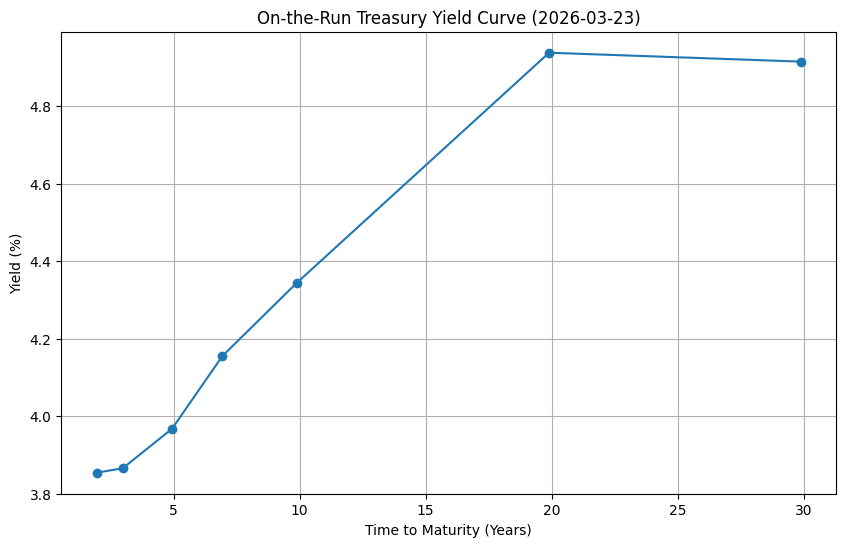

In [69]:
fig = plt.figure(figsize=(10, 6))
df = on_the_run_treasury.sort_values('TTM')
plt.plot(df['TTM'], df['midYield'], marker='o')
plt.title('On-the-Run Treasury Yield Curve (2026-03-23)')
plt.xlabel('Time to Maturity (Years)') 
plt.ylabel('Yield (%)')
plt.grid()
plt.show()

## b. Calibrate the on-the-run treasury yield curve (bootstrapping)
The function below shows how to calibrate a smooth yield/discount factor curve from the on-the-run treasury dataframe. 

Calibrate the bid, ask and mid discount factor curves as of 2026-03-23.

Display the calibration results for the mid curve, using get_yield_curve_details_df().

In [70]:
def calibrate_yield_curve_from_frame(
        calc_date: ql.Date,
        treasury_details: pd.DataFrame,
        price_quote_column: str):
    '''Create a calibrated yield curve from a details dataframe which includes bid/ask/mid price quotes.
    '''
    ql.Settings.instance().evaluationDate = calc_date

    # Sort dataframe by maturity
    sorted_details_frame = treasury_details.sort_values(by='maturity')    
    
    # For US Treasuries use ql.ActualActual(ql.ActualActual.ISMA)
    day_count = ql.ActualActual(ql.ActualActual.ISMA)

    bond_helpers = []
    
    for index, row in sorted_details_frame.iterrows():
        bond_object = create_bond_from_symbology(row)
        
        tsy_clean_price_quote = row[price_quote_column]
        tsy_clean_price_handle = ql.QuoteHandle(ql.SimpleQuote(tsy_clean_price_quote))
        
        bond_helper = ql.BondHelper(tsy_clean_price_handle, bond_object)
        bond_helpers.append(bond_helper)
        
    yield_curve = ql.PiecewiseLogCubicDiscount(calc_date, bond_helpers, day_count)
    # yield_curve = ql.PiecewiseFlatForward(calc_date, bond_helpers, day_count)
    
    yield_curve.enableExtrapolation()
    return yield_curve


def get_yield_curve_details_df(yield_curve, curve_dates=None):
    
    if(curve_dates == None):
        curve_dates = yield_curve.dates()

    dates = [d.to_date() for d in curve_dates]
    discounts = [round(yield_curve.discount(d), 3) for d in curve_dates]
    yearfracs = [round(yield_curve.timeFromReference(d), 3) for d in curve_dates]
    zeroRates = [round(yield_curve.zeroRate(d, yield_curve.dayCounter(), ql.Compounded).rate() * 100, 3) for d in curve_dates]

    yield_curve_details_df = pd.DataFrame(data={'Date': dates,
                             'YearFrac': yearfracs,
                             'DiscountFactor': discounts,
                             'ZeroRate': zeroRates})                             
    return yield_curve_details_df

In [71]:
on_the_run_treasury_yield_curve = calibrate_yield_curve_from_frame(calc_date, on_the_run_treasury, 'midPrice')
yield_curve_details_df = get_yield_curve_details_df(on_the_run_treasury_yield_curve)
yield_curve_details_df.head()

,Date,YearFrac,DiscountFactor,ZeroRate
0,2026-03-23,0.000,1.000,3.993
1,2028-02-29,1.917,0.929,3.909
2,2029-03-15,3.000,0.893,3.848
3,2031-02-28,4.917,0.824,4.014
4,2033-02-28,6.917,0.751,4.224


## c. Plot the calibrated US Treasury yield (zero rate) curves

Create a graph/scatter plot of the newly computed mid yields by maturity.

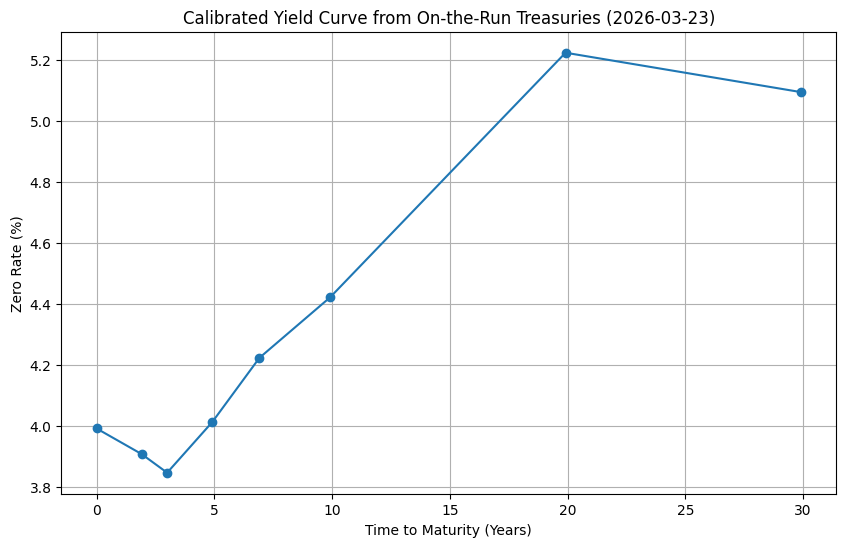

In [72]:
plt.figure(figsize=(10, 6))
plt.plot(yield_curve_details_df['YearFrac'], yield_curve_details_df['ZeroRate'], marker='o')
plt.title('Calibrated Yield Curve from On-the-Run Treasuries (2026-03-23)')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Zero Rate (%)')
plt.grid()
plt.show()

## d. Plot calibrated discount factors

Plot the discount factor curve up to the 30 years point, using a 6 months discretization grid.

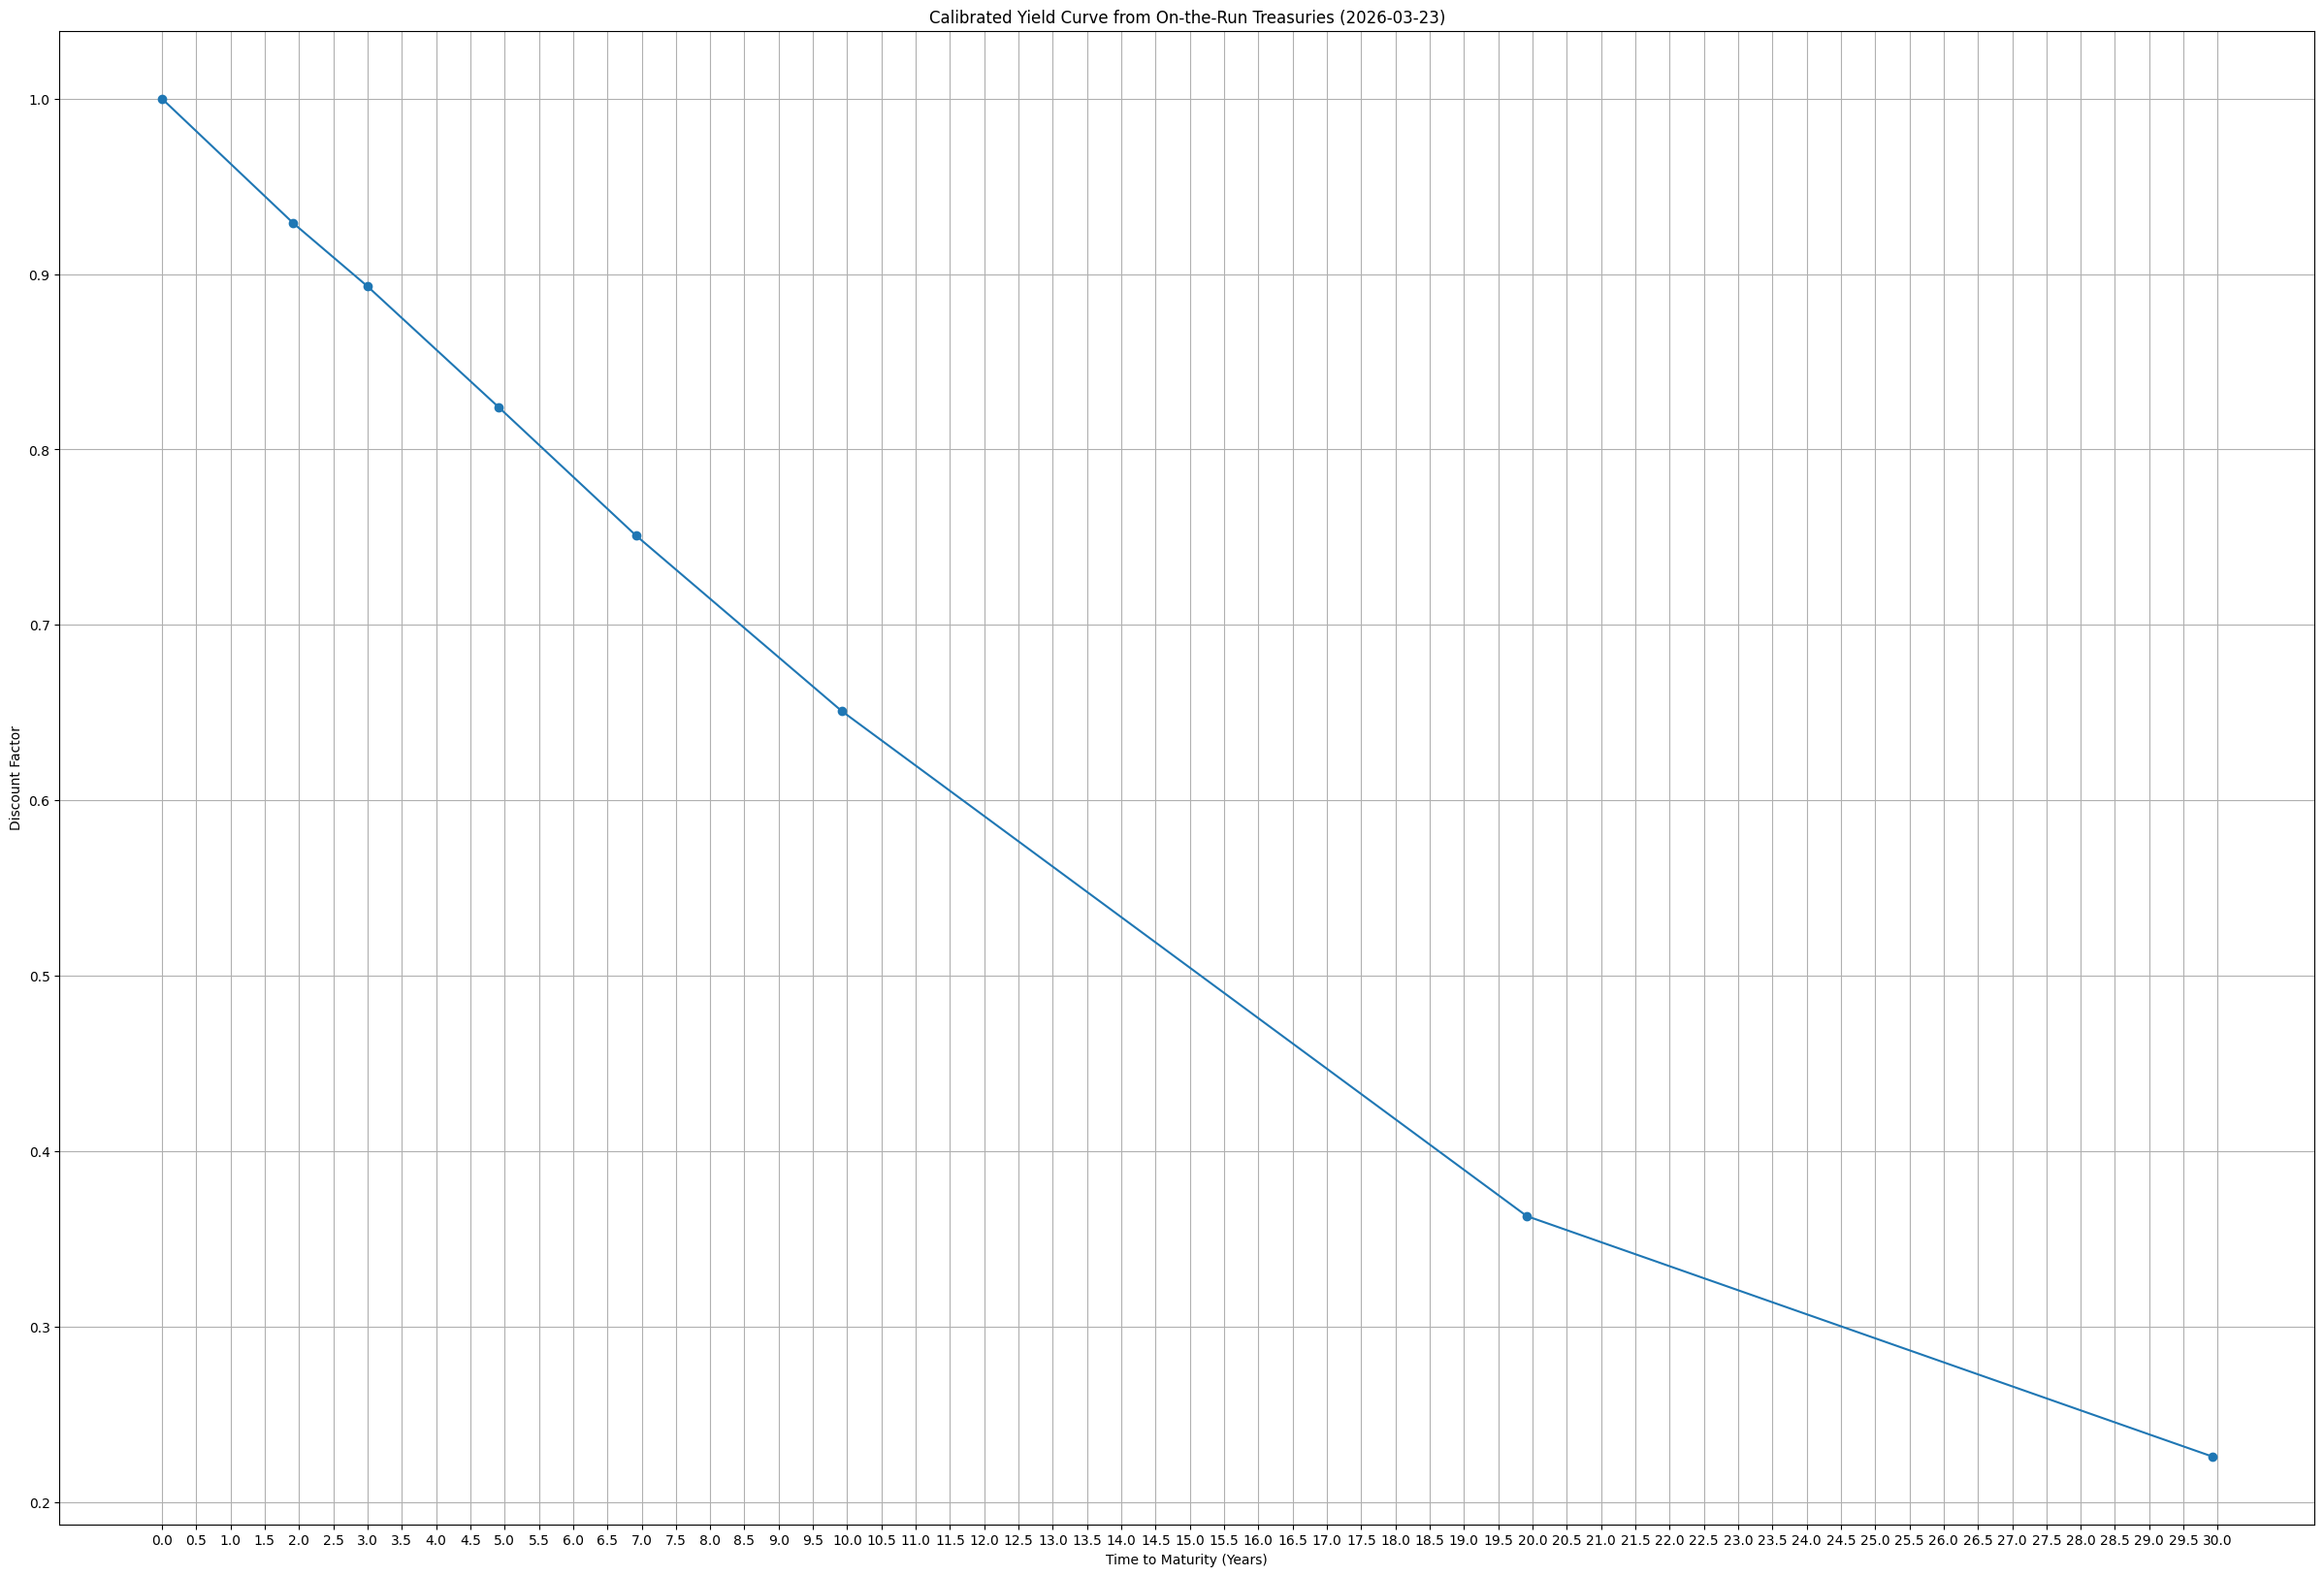

In [73]:
import numpy as np

plt.figure(figsize=(30, 20))
plt.plot(yield_curve_details_df['YearFrac'], yield_curve_details_df['DiscountFactor'], marker='o')
plt.title('Calibrated Yield Curve from On-the-Run Treasuries (2026-03-23)')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Discount Factor')

# Set x-ticks every 0.5 years
max_year = yield_curve_details_df['YearFrac'].max()
plt.xticks(np.arange(0, max_year + 0.5, 0.5))

plt.grid()
plt.show()


------------------------------------------------------------------------------------------
# Problem 3: Pricing and risk metrics for US Treasury bonds

## a. US Treasury pricing on the calibrated discount factor curve

Follow Section 5. "Bond Present Value Calculation (no credit risk)" in the QuantLib Basic notebook to re-price the US on-the-run treasuries using the calibrated discount factor curve. 

You will need to switch the bond_engine to use the new on-the-run treasury yield curve:
bond_engine = ql.DiscountingBondEngine(tsy_yield_curve_mid)

Extend the dataframe with the following computed columns for clean mid prices:


| calc_mid_price |
|---------------|


To validate the calibration, compare the calculated clean mid prices to the original market mid prices.

In [74]:
tsy_yield_curve_mid = ql.YieldTermStructureHandle(on_the_run_treasury_yield_curve)
bond_engine = ql.DiscountingBondEngine(tsy_yield_curve_mid)

for index, row in on_the_run_treasury.iterrows():
    bond_object = create_bond_from_symbology(row)
    bond_object.setPricingEngine(bond_engine)
    npv = bond_object.NPV()
    calc_mid_price = bond_object.cleanPrice()
    on_the_run_treasury.at[index, 'calc_mid_price'] = calc_mid_price


display(on_the_run_treasury[['ticker', 'maturity', 'midPrice', 'calc_mid_price']])


,ticker,maturity,midPrice,calc_mid_price
0,T,2028-02-29,99.15815,99.15815
1,T,2029-03-15,99.04290,99.04290
2,T,2031-02-28,98.00780,98.00780
3,T,2033-02-28,97.66400,97.66400
4,T,2036-02-15,98.32810,98.32810
5,T,2046-02-15,96.09370,96.09370
6,T,2056-02-15,97.47655,97.47655


## b. Compute analytical DV01, Duration and Convexity for US on-the-run treasuries (using flat yield)

Compute analytical DV01, Duration and Convexity metrics, as described in Section 7. "Analytics Duration, Convexity and Z-Spread (flat yield model)" in the QuantLib Basic notebook.

Remember that DV01 = Dirty_Price * Duration. 

Extend the dataframe with the following calculated risk metrics:


| dv01 | duration | convexity |
|-------|-------|-------------|


In [75]:
for index, row in on_the_run_treasury.iterrows():
    bond_object = create_bond_from_symbology(row)
    bond_object.setPricingEngine(bond_engine)
    
    day_count = ql.ActualActual(ql.ActualActual.ISMA)
    compounding = ql.Compounded
    frequency = ql.Semiannual

    bond_rate = ql.InterestRate(bond_object.bondYield(day_count, compounding, frequency), day_count, compounding, frequency)
    
    duration = ql.BondFunctions.duration(bond_object, bond_rate, ql.Duration.Modified)
    on_the_run_treasury.at[index, 'duration'] = duration
    convexity = ql.BondFunctions.convexity(bond_object, bond_rate)
    on_the_run_treasury.at[index, 'convexity'] = convexity
    dv01 = duration * bond_object.NPV() / 10000
    on_the_run_treasury.at[index, 'DV01'] = dv01

display(on_the_run_treasury[['ticker', 'maturity', 'duration', 'convexity', 'DV01']])

,ticker,maturity,duration,convexity,DV01
0,T,2028-02-29,1.849877,4.383082,0.018382
1,T,2029-03-15,2.795028,9.393459,0.027704
2,T,2031-02-28,4.472110,23.214862,0.043928
3,T,2033-02-28,6.019917,42.078428,0.058934
4,T,2036-02-15,8.001085,76.180264,0.079002
5,T,2046-02-15,12.690655,214.885670,0.122536
6,T,2056-02-15,15.619031,358.459404,0.152991


## c. Compute scenario DV01, Duration and Convexity for US on-the-run treasuries (using calibrated yield curve)

Compute the scenario DV01, Duration and Convexity metrics using +/-1bp interest rate shocks, as described in Section 6. "Market Data Scenarios" in the QuantLib Basic notebook.

Remember that DV01 = Dirty_Price * Duration.

Extend the dataframe with the following scenario sensitivities metrics:

| scen_dv01 | scen_duration | scen_convexity |
|-------|-------|-------------|



In [76]:
interest_rate_bump = ql.SimpleQuote(0.0)
tsy_yield_curve_bumped = ql.ZeroSpreadedTermStructure(tsy_yield_curve_mid, ql.QuoteHandle(interest_rate_bump))
bond_engine_scen = ql.DiscountingBondEngine(ql.YieldTermStructureHandle(tsy_yield_curve_bumped))

bump = 0.0001  

for index, row in on_the_run_treasury.iterrows():
    bond_object = create_bond_from_symbology(row)
    bond_object.setPricingEngine(bond_engine_scen)

    interest_rate_bump.setValue(0.0)
    price_base = bond_object.cleanPrice()
    dirty_price_base = bond_object.dirtyPrice()

    interest_rate_bump.setValue(0.0001)
    price_up = bond_object.cleanPrice()

    interest_rate_bump.setValue(-0.0001)
    price_down = bond_object.cleanPrice()

    interest_rate_bump.setValue(0.0)

    dv01 = round(price_down - price_base, 4)
    duration = round((price_down - price_up) / (2 * bump) / dirty_price_base, 4)
    convexity = round((price_up - 2*price_base + price_down) / (bump**2) / dirty_price_base, 4)


    on_the_run_treasury.at[index, 'scen_dv01'] = dv01
    on_the_run_treasury.at[index, 'scen_duration'] = duration
    on_the_run_treasury.at[index, 'scen_convexity'] = convexity

display(on_the_run_treasury[['ticker', 'maturity', 'scen_dv01', 'scen_duration', 'scen_convexity']])



,ticker,maturity,scen_dv01,scen_duration,scen_convexity
0,T,2028-02-29,0.0185,1.8644,3.5317
1,T,2029-03-15,0.0285,2.8706,8.4585
2,T,2031-02-28,0.0446,4.5387,21.6645
3,T,2033-02-28,0.0599,6.1188,40.4622
4,T,2036-02-15,0.0808,8.1738,75.4627
5,T,2046-02-15,0.1236,12.7881,213.4364
6,T,2056-02-15,0.1537,15.6755,357.1492


------------------------------------------------------------------------------------------
# Problem 4: Pricing and risk metrics for corporate bonds

## a. Create the fixed-rate corporate bond objects

Restrict the symbology dataframe to fixed rate corporate bonds only and create the corporate bond objects. 

Display the future cashflows for the `AAPL 1.65 05/11/30` bond.

In [77]:
bond_symbology = pd.read_excel('data/bond_symbology.xlsx')
bond_market_prices_eod = pd.read_excel('data/bond_market_prices_eod.xlsx')
bond_symbology = bond_symbology[(bond_symbology['class'] == 'Corp') & (bond_symbology['cpn_type'] == 'FIXED')]
bond_symbology = bond_symbology.merge(bond_market_prices_eod[['figi', 'isin', 'bidPrice', 'askPrice', 'bidYield', 'askYield']], on=['figi', 'isin'], how='inner')
bond_symbology['midPrice'] = (bond_symbology['bidPrice'] + bond_symbology['askPrice']) / 2
bond_symbology['midYield'] = (bond_symbology['bidYield'] + bond_symbology['askYield']) / 2
display(bond_symbology.head())



,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,amt_out,country,currency,status,bidPrice,askPrice,bidYield,askYield,midPrice,midYield
0,AAPL,Corp,BBG004HST0K7,US037833AL42,US912810UT33,AAPL 3.85 05/04/43,APPLE INC,GLOBAL,3.850,FIXED,...,3000.0,US,USD,ACTV,82.414444,82.414444,5.442,5.442,82.414444,5.442
1,AAPL,Corp,BBG006F8VWJ7,US037833AT77,US912810UT33,AAPL 4.45 05/06/44,APPLE INC,GLOBAL,4.450,FIXED,...,1000.0,US,USD,ACTV,89.116091,89.116091,5.399,5.399,89.116091,5.399
2,AAPL,Corp,BBG0081TNL50,US037833BA77,US912810UT33,AAPL 3.45 02/09/45,APPLE INC,GLOBAL,3.450,FIXED,...,2000.0,US,USD,ACTV,75.855577,75.855577,5.526,5.526,75.855577,5.526
3,AAPL,Corp,BBG008N1BQC1,US037833BH21,US912810UT33,AAPL 4 3/8 05/13/45,APPLE INC,GLOBAL,4.375,FIXED,...,2000.0,US,USD,ACTV,86.818216,86.818216,5.497,5.497,86.818216,5.497
4,AAPL,Corp,BBG00C7QBCQ1,US037833BW97,US91282CPZ85,AAPL 4 1/2 02/23/36,APPLE INC,GLOBAL,4.500,FIXED,...,1250.0,US,USD,ACTV,99.575093,99.575093,4.553,4.553,99.575093,4.553


In [78]:
aapl_bond_details = bond_symbology[bond_symbology['security'] == 'AAPL 1.65 05/11/30'].iloc[0].to_dict()
aapl_bond = create_bond_from_symbology(aapl_bond_details)
display(get_bond_cashflows(aapl_bond, calc_date))

,CashFlowDate,CashFlowAmount,CashFlowYearFrac
0,"May 11th, 2026",0.825,0.133333
1,"November 11th, 2026",0.825,0.633333
2,"May 11th, 2027",0.825,1.133333
3,"November 11th, 2027",0.825,1.633333
4,"May 11th, 2028",0.825,2.133333
5,"November 11th, 2028",0.825,2.633333
6,"May 11th, 2029",0.825,3.133333
7,"November 11th, 2029",0.825,3.633333
8,"May 11th, 2030",0.825,4.133333
9,"May 11th, 2030",100.000,4.133333


## b. Compute analytical Yields and Z-Spreads

Compute analytical Yields and Z-Spreads metrics, as described in Section 7. "Analytical Duration, Convexity and Z-Spread (flat yield model)" in the QuantLib Basic notebook.

Extend the dataframe with the following calculated risk metrics:


| calc_yield | calc_zspread |
|-------|-------------|


In [79]:
day_count = ql.ActualActual(ql.ActualActual.ISMA)
compounding = ql.Compounded
frequency = ql.Semiannual

for index, row in bond_symbology.iterrows():
    bond_object = create_bond_from_symbology(row)
    bond_object.setPricingEngine(bond_engine)

    market_clean_price = row['midPrice']
    bond_price = ql.BondPrice(market_clean_price, ql.BondPrice.Clean)

    calc_yield = bond_object.bondYield(bond_price, day_count, compounding, frequency) * 100
    bond_symbology.at[index, 'calc_yield'] = round(calc_yield, 4)


    bond_z_spread = ql.BondFunctions.zSpread(
        bond_object, bond_price,
        tsy_yield_curve_mid.currentLink(),
        day_count, compounding, frequency)

    bond_symbology.at[index, 'calc_zspread'] = round(bond_z_spread * 10000, 4)

display(bond_symbology[['security', 'midYield', 'calc_yield', 'calc_zspread']])
    
    

,security,midYield,calc_yield,calc_zspread
0,AAPL 3.85 05/04/43,5.442,5.4410,58.4437
1,AAPL 4.45 05/06/44,5.399,5.3977,50.8869
2,AAPL 3.45 02/09/45,5.526,5.5233,57.7326
3,AAPL 4 3/8 05/13/45,5.497,5.4957,57.6149
4,AAPL 4 1/2 02/23/36,4.553,4.5499,23.1832
...,...,...,...,...
326,VZ 5 3/4 11/30/45,6.010,6.0083,114.9114
327,VZ 5 7/8 11/30/55,6.086,6.0845,122.1360
328,VZ 6 11/30/65,6.214,6.2125,139.7990
329,VZ 7 3/4 12/01/30,4.708,4.7039,80.1790


## c. Validate Z-Spread computation for a few fixed rate corporate bonds

For the following corporate bonds:

* `IBM 5 7/8 11/29/32`
* `T 4 1/2 02/15/36`
* `DIS 6.2 12/15/34`

use function below to re-price them using the calibrated flat z-spread. Follow the example in Section 7. "Analytical Duration, Convexity and Z-Spread (flat yield model)".

Validate/confirm that you match the original market prices, which were used as input to the z-Spread function.


In [80]:
def calc_clean_price_with_zspread(fixed_rate_bond, yield_curve_handle, zspread):
    zspread_quote = ql.SimpleQuote(zspread)
    zspread_quote_handle = ql.QuoteHandle(zspread_quote)
    yield_curve_bumped = ql.ZeroSpreadedTermStructure(yield_curve_handle, zspread_quote_handle, ql.Compounded, ql.Semiannual)
    yield_curve_bumped_handle = ql.YieldTermStructureHandle(yield_curve_bumped)
    
    # Set Valuation engine
    bond_engine = ql.DiscountingBondEngine(yield_curve_bumped_handle)
    fixed_rate_bond.setPricingEngine(bond_engine)
    bond_clean_price = fixed_rate_bond.cleanPrice()
    return bond_clean_price


In [81]:

target_bonds = ['IBM 5 7/8 11/29/32', 'T 4 1/2 02/15/36', 'DIS 6.2 12/15/34']
target_df = bond_symbology[bond_symbology['security'].isin(target_bonds)].copy()

day_count = ql.ActualActual(ql.ActualActual.ISMA)
compounding = ql.Compounded
frequency = ql.Semiannual

for index, row in target_df.iterrows():
    bond_object = create_bond_from_symbology(row)
    
    zspread = row['calc_zspread'] / 10000
    
    
    repriced_clean_price = calc_clean_price_with_zspread(
        bond_object, tsy_yield_curve_mid, zspread)
    
    target_df.at[index, 'repriced_clean_price'] = round(repriced_clean_price, 4)

display(target_df[['security', 'midPrice', 'repriced_clean_price', 'calc_zspread']])

,security,midPrice,repriced_clean_price,calc_zspread
43,DIS 6.2 12/15/34,109.999289,109.9993,52.7208
133,IBM 5 7/8 11/29/32,106.248959,106.2490,66.0099


Note: ```T 4 1/2 02/15/36``` is not a corporate bond therefore not included in the result.

## d. Compute Duration and Convexity for fixed rate corporate bonds (using flat yield)

Compute analytical Duration and Convexity metrics, as described in Section 7. "Analytical Duration, Convexity and Z-Spread (flat yield model)" in the QuantLib Basic notebook.

Extend the dataframe with the following calculated risk metrics:


| calc_duration | calc_convexity |
|-------|-------------|

Display the head of the dataframe.

Scatter plot duration and convexity by TTM for all `AAPL` (VERIZON COMMUNICATIONS) fixed-rate bonds.

,security,midPrice,calc_yield,calc_zspread,calc_duration,calc_convexity
0,AAPL 3.85 05/04/43,82.414444,5.4410,58.4437,11.6314,176.0139
1,AAPL 4.45 05/06/44,89.116091,5.3977,50.8869,11.7106,183.2195
2,AAPL 3.45 02/09/45,75.855577,5.5233,57.7326,12.7580,211.1329
3,AAPL 4 3/8 05/13/45,86.818216,5.4957,57.6149,12.1026,197.8375
4,AAPL 4 1/2 02/23/36,99.575093,4.5499,23.1832,7.8973,74.8367


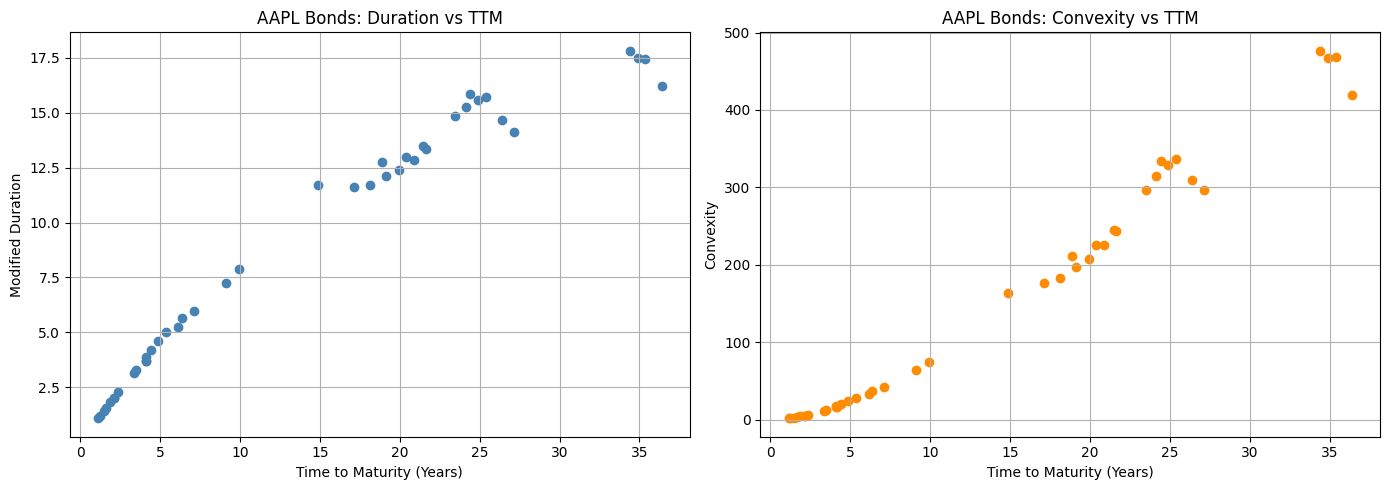

In [82]:
day_count = ql.ActualActual(ql.ActualActual.ISMA)
compounding = ql.Compounded
frequency = ql.Semiannual

for index, row in bond_symbology.iterrows():
    bond_object = create_bond_from_symbology(row)
    bond_object.setPricingEngine(bond_engine)

    # Use market price to get the flat yield, then build InterestRate object
    market_clean_price = ql.BondPrice(row['midPrice'], ql.BondPrice.Clean)
    flat_yield = bond_object.bondYield(market_clean_price, day_count, compounding, frequency)
    interest_rate = ql.InterestRate(flat_yield, day_count, compounding, frequency)

    calc_duration = ql.BondFunctions.duration(bond_object, interest_rate, ql.Duration.Modified)
    calc_convexity = ql.BondFunctions.convexity(bond_object, interest_rate)

    bond_symbology.at[index, 'calc_duration'] = round(calc_duration, 4)
    bond_symbology.at[index, 'calc_convexity'] = round(calc_convexity, 4)

display(bond_symbology[['security', 'midPrice', 'calc_yield', 'calc_zspread', 'calc_duration', 'calc_convexity']].head())

aapl_df = bond_symbology[bond_symbology['ticker'] == 'AAPL'].copy()
aapl_df['TTM'] = (pd.to_datetime(aapl_df['maturity']) - pd.Timestamp('2026-03-23')).dt.days / 365.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(aapl_df['TTM'], aapl_df['calc_duration'], color='steelblue')
ax1.set_title('AAPL Bonds: Duration vs TTM')
ax1.set_xlabel('Time to Maturity (Years)')
ax1.set_ylabel('Modified Duration')
ax1.grid()

ax2.scatter(aapl_df['TTM'], aapl_df['calc_convexity'], color='darkorange')
ax2.set_title('AAPL Bonds: Convexity vs TTM')
ax2.set_xlabel('Time to Maturity (Years)')
ax2.set_ylabel('Convexity')
ax2.grid()

plt.tight_layout()
plt.show()
